# Desafio Final — Análise Financeira ClearBank

Notebook de análise de transações financeiras: leitura, validação, métricas mensais,
detecção de transações suspeitas e exportação de relatório em JSON.

## Instruções

Este notebook faz a análise financeira das transações da ClearBank, seguindo o fluxo:

**leitura → validação → métricas mensais → transações suspeitas → exportação em JSON → relatório no terminal**

### Como executar

Execute as células em ordem, do início ao fim (`Runtime → Run all` no Colab, ou
`Kernel → Restart & Run All` no Jupyter).

### Colunas do `transacoes.csv`

| Coluna       | Tipo esperado | Descrição                                   |
|--------------|---------------|---------------------------------------------|
| `id`         | inteiro       | Identificador único da transação            |
| `data`       | texto         | Data no formato `AAAA-MM-DD`                |
| `cliente_id` | texto         | Código do cliente (não pode ser vazio)      |
| `tipo`       | texto         | `credito` ou `debito`                       |
| `valor`      | decimal       | Valor da transação (deve ser maior que 0)   |
| `descricao`  | texto         | Descrição livre da operação                 |
| `categoria`  | texto         | Ex.: `salario`, `compra`, `transferencia`   |

### Sobre o arquivo de dados

Como o arquito `transacoes.csv` **não foi** entregue pela proposta de trabalho, ele será gerado pela função
`gerar_csv_transacoes()`, definida mais abaixo. A quantidade de linhas é configurável
através da variável `QTD_LINHAS_CSV` (mínimo obrigatório: 30).

In [112]:
import csv
import json
from datetime import datetime, date

LIMITE_SUSPEITO = 10000.00
ARQUIVO_CSV = "transacoes.csv"
ARQUIVO_JSON = "relatorio.json"
FORMATO_DATA = "%Y-%m-%d"

def formatar_moeda(valor: float) -> str:
    """Formata um float como moeda brasileira: 3319.5 -> 'R$ 3.319,50'."""
    return f"R$ {valor:,.2f}".replace(",", "X").replace(".", ",").replace("X", ".")


In [113]:
print(formatar_moeda(3319.5))
print(formatar_moeda(15000))


R$ 3.319,50
R$ 15.000,00


## Geração do arquivo de dados (transacoes.csv)

In [114]:
import random
from datetime import timedelta

def gerar_csv_transacoes(qtd_linhas: int = 15, caminho: str = "transacoes.csv") -> None:
    """Gera o arquivo transacoes.csv com dados sintéticos.

    - qtd_linhas: total de linhas de dados (sem contar o cabeçalho). Mínimo: 30.
    - Garante: >= 5 linhas inválidas (uma de cada tipo de erro),
      >= 2 transações válidas acima de R$ 10.000,00,
      transações válidas distribuídas em pelo menos 3 meses.
    """
    if qtd_linhas < 15:
        raise ValueError("A quantidade mínima de linhas é 15.")

    random.seed(42)

    clientes = ["CLI001", "CLI002", "CLI003", "CLI004", "CLI005", "CLI006", "CLI007"]
    pares_desc_categoria = [
        ("Salário mensal", "salario"),
        ("Supermercado", "compra"),
        ("Conta de luz", "conta"),
        ("Streaming", "assinatura"),
        ("Transferência recebida", "transferencia"),
    ]
    meses_base = [date(2026, 1, 1), date(2026, 2, 1), date(2026, 3, 1), date(2026, 4, 1), date(2026, 5, 1), date(2026, 6, 1)]

    def data_aleatoria():
        mes = random.choice(meses_base)
        dia = random.randint(1, 28)
        return mes.replace(day=dia)

    linhas = []
    proximo_id = 1

    # 2 transações válidas suspeitas (valor entre 10000.01 e 25000.00)
    for _ in range(2):
        descricao, categoria = random.choice(pares_desc_categoria)
        linhas.append({
            "id": proximo_id,
            "data": data_aleatoria().strftime("%Y-%m-%d"),
            "cliente_id": random.choice(clientes),
            "tipo": random.choice(["credito", "debito"]),
            "valor": round(random.uniform(10000.01, 25000.00), 2),
            "descricao": descricao,
            "categoria": categoria,
        })
        proximo_id += 1

    # 5 linhas inválidas, uma de cada tipo de erro
    descricao, categoria = random.choice(pares_desc_categoria)
    linhas.append({  # 1. id vazio ou não numérico
        "id": "abc", "data": data_aleatoria().strftime("%Y-%m-%d"),
        "cliente_id": random.choice(clientes), "tipo": random.choice(["credito", "debito"]),
        "valor": round(random.uniform(10, 5000), 2), "descricao": descricao, "categoria": categoria,
    })
    proximo_id += 1

    descricao, categoria = random.choice(pares_desc_categoria)
    linhas.append({  # 2. cliente_id vazio
        "id": proximo_id, "data": data_aleatoria().strftime("%Y-%m-%d"),
        "cliente_id": "", "tipo": random.choice(["credito", "debito"]),
        "valor": round(random.uniform(10, 5000), 2), "descricao": descricao, "categoria": categoria,
    })
    proximo_id += 1

    descricao, categoria = random.choice(pares_desc_categoria)
    linhas.append({  # 3. data em formato inválido
        "id": proximo_id, "data": "15/01/2026",
        "cliente_id": random.choice(clientes), "tipo": random.choice(["credito", "debito"]),
        "valor": round(random.uniform(10, 5000), 2), "descricao": descricao, "categoria": categoria,
    })
    proximo_id += 1

    descricao, categoria = random.choice(pares_desc_categoria)
    linhas.append({  # 4. tipo diferente de credito/debito
        "id": proximo_id, "data": data_aleatoria().strftime("%Y-%m-%d"),
        "cliente_id": random.choice(clientes), "tipo": "pix",
        "valor": round(random.uniform(10, 5000), 2), "descricao": descricao, "categoria": categoria,
    })
    proximo_id += 1

    descricao, categoria = random.choice(pares_desc_categoria)
    linhas.append({  # 5. valor não numérico ou <= 0
        "id": proximo_id, "data": data_aleatoria().strftime("%Y-%m-%d"),
        "cliente_id": random.choice(clientes), "tipo": random.choice(["credito", "debito"]),
        "valor": "abc", "descricao": descricao, "categoria": categoria,
    })
    proximo_id += 1

    # linhas restantes: transações válidas normais, garantindo 3+ meses distintos
    qtd_restante = qtd_linhas - len(linhas)
    for i in range(qtd_restante):
        descricao, categoria = random.choice(pares_desc_categoria)
        # garante que os primeiros 4 registros cubram os 4 meses base
        mes = meses_base[i] if i < len(meses_base) else random.choice(meses_base)
        dia = random.randint(1, 28)
        linhas.append({
            "id": proximo_id,
            "data": mes.replace(day=dia).strftime("%Y-%m-%d"),
            "cliente_id": random.choice(clientes),
            "tipo": random.choice(["credito", "debito"]),
            "valor": round(random.uniform(10.00, 5000.00), 2),
            "descricao": descricao,
            "categoria": categoria,
        })
        proximo_id += 1

    random.shuffle(linhas)

    with open(caminho, "w", newline="", encoding="utf-8") as f:
        campos = ["id", "data", "cliente_id", "tipo", "valor", "descricao", "categoria"]
        escritor = csv.writer(f)
        escritor.writerow(campos)
        for linha in linhas:
            escritor.writerow([linha[c] for c in campos])


In [115]:
QTD_LINHAS_CSV = 50  # <-- altere aqui a quantidade desejada (mínimo 15)
gerar_csv_transacoes(QTD_LINHAS_CSV)


In [116]:
with open(ARQUIVO_CSV, "r", encoding="utf-8") as f:
    linhas_cruas = f.readlines()

print("Primeiras 10 linhas do arquivo gerado:")
for linha in linhas_cruas[:10]:
    print(linha.strip())

print(f"\nTotal de linhas de dados: {len(linhas_cruas) - 1}")

try:
    gerar_csv_transacoes(10)
except ValueError:
    print("Validação de mínimo OK")


Primeiras 10 linhas do arquivo gerado:
id,data,cliente_id,tipo,valor,descricao,categoria
35,2026-04-17,CLI004,credito,1247.05,Conta de luz,conta
36,2026-03-01,CLI005,credito,2946.32,Salário mensal,salario
14,2026-02-12,CLI003,credito,3354.17,Conta de luz,conta
31,2026-05-03,CLI001,debito,4081.96,Supermercado,compra
32,2026-02-05,CLI006,debito,4734.77,Transferência recebida,transferencia
18,2026-02-19,CLI006,debito,1071.01,Salário mensal,salario
48,2026-04-10,CLI004,debito,782.44,Conta de luz,conta
24,2026-04-20,CLI004,debito,4855.68,Streaming,assinatura
19,2026-04-21,CLI004,credito,1331.75,Streaming,assinatura

Total de linhas de dados: 50
Validação de mínimo OK


## Leitura do CSV

In [117]:
def ler_transacoes(caminho: str = ARQUIVO_CSV) -> list[dict]:
    """Lê o CSV e retorna a lista de transações brutas (cada linha como dict).

    Retorna lista vazia se o arquivo não existir (e avisa no terminal).
    """
    try:
        with open(caminho, "r", encoding="utf-8", newline="") as arquivo:
            leitor = csv.DictReader(arquivo)
            return list(leitor)
    except FileNotFoundError:
        print(f"ERRO: arquivo '{caminho}' não encontrado. Gere o CSV antes de continuar.")
        return []


In [118]:
transacoes_brutas = ler_transacoes()
print(f"Total de linhas lidas: {len(transacoes_brutas)}")
print("Primeira linha:", transacoes_brutas[0] if transacoes_brutas else "arquivo vazio")

# Teste do FileNotFoundError: deve imprimir o aviso e retornar []
assert ler_transacoes("nao_existe.csv") == []
print("Tratamento de arquivo inexistente OK")


Total de linhas lidas: 50
Primeira linha: {'id': '35', 'data': '2026-04-17', 'cliente_id': 'CLI004', 'tipo': 'credito', 'valor': '1247.05', 'descricao': 'Conta de luz', 'categoria': 'conta'}
ERRO: arquivo 'nao_existe.csv' não encontrado. Gere o CSV antes de continuar.
Tratamento de arquivo inexistente OK


## Validação e limpeza

In [119]:
def validar_data(texto: str) -> datetime:
    """Retorna datetime se o texto estiver no formato AAAA-MM-DD, senão None."""
    try:
        return datetime.strptime(texto.strip(), FORMATO_DATA)
    except (ValueError, AttributeError):
        return None

def validar_valor(texto: str) -> float:
    """Retorna float se o texto for numérico e > 0, senão None."""
    try:
        valor = float(texto)
    except (ValueError, TypeError):
        return None
    return valor if valor > 0 else None


In [120]:
def validar_transacao(linha: dict) -> dict:
    """Valida uma linha bruta. Retorna o registro limpo (tipos convertidos) ou None se inválida.

    Registro limpo: {"id": int, "data": datetime, "cliente_id": str,
                     "tipo": str, "valor": float, "descricao": str, "categoria": str}
    """
    try:
        id_transacao = int(linha.get("id", ""))
    except ValueError:
        return None

    cliente_id = linha.get("cliente_id", "").strip()
    if not cliente_id:
        return None

    data = validar_data(linha.get("data", ""))
    if data is None:
        return None

    tipo = linha.get("tipo", "").strip().lower()
    if tipo not in ("credito", "debito"):
        return None

    valor = validar_valor(linha.get("valor", ""))
    if valor is None:
        return None

    return {
        "id": id_transacao,
        "data": data,
        "cliente_id": cliente_id,
        "tipo": tipo,
        "valor": valor,
        "descricao": linha.get("descricao", "").strip(),
        "categoria": linha.get("categoria", "").strip(),
    }


In [121]:
def limpar_transacoes(brutas: list[dict]) -> tuple[list[dict], int]:
    """Valida todas as linhas. Retorna (lista_validas, qtd_invalidas)."""
    validas = []
    invalidas = 0
    for linha in brutas:
        registro = validar_transacao(linha)
        if registro is None:
            invalidas += 1
        else:
            validas.append(registro)
    return validas, invalidas


In [122]:
transacoes_brutas = ler_transacoes()
transacoes, qtd_invalidas = limpar_transacoes(transacoes_brutas)
print(f"Total de linhas lidas: {len(transacoes_brutas)}")
print(f"Linhas válidas: {len(transacoes)}")
print(f"Linhas inválidas: {qtd_invalidas}")


Total de linhas lidas: 50
Linhas válidas: 45
Linhas inválidas: 5


## Manipulação de datas

In [123]:
def extrair_mes(transacao: dict) -> str:
    """Retorna o mês da transação no formato AAAA-MM (ex.: '2026-01')."""
    return transacao["data"].strftime("%Y-%m")

def calcular_periodo(transacoes: list[dict]) -> tuple[datetime, datetime, int]:
    """Retorna (data_mais_antiga, data_mais_recente, dias_entre_elas)."""
    datas = [t["data"] for t in transacoes]
    mais_antiga = min(datas)
    mais_recente = max(datas)
    dias = (mais_recente - mais_antiga).days
    return mais_antiga, mais_recente, dias


In [124]:
mais_antiga, mais_recente, dias = calcular_periodo(transacoes)
print(f"Período: {mais_antiga.strftime(FORMATO_DATA)} -> {mais_recente.strftime(FORMATO_DATA)} ({dias} dias)")
print("Meses presentes:", sorted({extrair_mes(t) for t in transacoes}))


Período: 2026-01-02 -> 2026-06-28 (177 dias)
Meses presentes: ['2026-01', '2026-02', '2026-03', '2026-04', '2026-05', '2026-06']


## Agrupamento mensal e métricas

In [125]:
def gerar_relatorio(transacoes: list[dict]) -> dict:
    """Agrupa por mês (AAAA-MM) e calcula as métricas.

    Retorna: {"2026-01": {"quantidade": ..., "total_credito": ..., "total_debito": ...,
                          "saldo": ..., "media": ..., "maior_valor": ..., "menor_valor": ...}, ...}
    """
    resumo = {}
    for t in transacoes:
        mes = extrair_mes(t)
        if mes not in resumo:
            resumo[mes] = {"quantidade": 0, "total_credito": 0.0, "total_debito": 0.0,
                           "valores": []}
        resumo[mes]["quantidade"] += 1
        resumo[mes]["valores"].append(t["valor"])
        if t["tipo"] == "credito":
            resumo[mes]["total_credito"] += t["valor"]
        else:
            resumo[mes]["total_debito"] += t["valor"]

    # segunda passada: métricas derivadas + remoção da lista auxiliar
    for mes, dados in resumo.items():
        valores = dados.pop("valores")
        dados["saldo"] = round(dados["total_credito"] - dados["total_debito"], 2)
        dados["media"] = round(sum(valores) / len(valores), 2)
        dados["maior_valor"] = max(valores)
        dados["menor_valor"] = min(valores)
        dados["total_credito"] = round(dados["total_credito"], 2)
        dados["total_debito"] = round(dados["total_debito"], 2)

    # retorna com meses em ordem cronológica
    return dict(sorted(resumo.items()))


In [126]:
resumo_mensal = gerar_relatorio(transacoes)
for mes, dados in resumo_mensal.items():
    print(mes, dados)


2026-01 {'quantidade': 9, 'total_credito': 26840.48, 'total_debito': 8232.42, 'saldo': 18608.06, 'media': 3896.99, 'maior_valor': 13348.17, 'menor_valor': 293.83}
2026-02 {'quantidade': 9, 'total_credito': 11962.42, 'total_debito': 10826.26, 'saldo': 1136.16, 'media': 2532.08, 'maior_valor': 4865.85, 'menor_valor': 709.51}
2026-03 {'quantidade': 6, 'total_credito': 9993.37, 'total_debito': 8970.9, 'saldo': 1022.47, 'media': 3160.71, 'maior_valor': 4822.17, 'menor_valor': 1399.6}
2026-04 {'quantidade': 7, 'total_credito': 12773.02, 'total_debito': 5638.12, 'saldo': 7134.9, 'media': 2630.16, 'maior_valor': 4855.68, 'menor_valor': 782.44}
2026-05 {'quantidade': 7, 'total_credito': 17471.56, 'total_debito': 9008.22, 'saldo': 8463.34, 'media': 3782.83, 'maior_valor': 4986.66, 'menor_valor': 825.38}
2026-06 {'quantidade': 7, 'total_credito': 19630.06, 'total_debito': 13967.05, 'saldo': 5663.01, 'media': 4799.59, 'maior_valor': 18857.39, 'menor_valor': 772.67}


## Transações suspeitas

In [127]:
def identificar_suspeitas(transacoes: list[dict]) -> list[dict]:
    """Retorna as transações com valor acima de LIMITE_SUSPEITO.

    Cada item: {"id": int, "cliente_id": str, "data": "AAAA-MM-DD", "valor": float}
    (formato já pronto para o JSON da Task 09).
    """
    suspeitas = []
    for t in transacoes:
        if t["valor"] > LIMITE_SUSPEITO:
            suspeitas.append({
                "id": t["id"],
                "cliente_id": t["cliente_id"],
                "data": t["data"].strftime(FORMATO_DATA),
                "valor": t["valor"],
            })
    return suspeitas


In [128]:
suspeitas = identificar_suspeitas(transacoes)
print(f"Suspeitas encontradas: {len(suspeitas)}")
for s in suspeitas:
    print(s)


Suspeitas encontradas: 2
{'id': 2, 'cliente_id': 'CLI005', 'data': '2026-06-24', 'valor': 18857.39}
{'id': 1, 'cliente_id': 'CLI003', 'data': '2026-01-24', 'valor': 13348.17}


## Exportação para JSON

In [129]:
def salvar_json(resumo_mensal: dict, suspeitas: list[dict],
                qtd_validas: int, qtd_invalidas: int,
                caminho: str = ARQUIVO_JSON) -> dict:
    """Monta o relatório final e salva em relatorio.json. Retorna o dict salvo."""
    relatorio = {
        "gerado_em": date.today().strftime(FORMATO_DATA),
        "total_transacoes_validas": qtd_validas,
        "total_transacoes_invalidas": qtd_invalidas,
        "resumo_mensal": resumo_mensal,
        "transacoes_suspeitas": suspeitas,
    }
    with open(caminho, "w", encoding="utf-8") as arquivo:
        json.dump(relatorio, arquivo, ensure_ascii=False, indent=2)
    return relatorio


In [130]:
relatorio = salvar_json(resumo_mensal, suspeitas, len(transacoes), qtd_invalidas)
print(f"Arquivo {ARQUIVO_JSON} salvo.")

# reabre para conferir que é JSON válido
with open(ARQUIVO_JSON, "r", encoding="utf-8") as f:
    conferencia = json.load(f)
print(json.dumps(conferencia, ensure_ascii=False, indent=2)[:500])


Arquivo relatorio.json salvo.
{
  "gerado_em": "2026-07-21",
  "total_transacoes_validas": 45,
  "total_transacoes_invalidas": 5,
  "resumo_mensal": {
    "2026-01": {
      "quantidade": 9,
      "total_credito": 26840.48,
      "total_debito": 8232.42,
      "saldo": 18608.06,
      "media": 3896.99,
      "maior_valor": 13348.17,
      "menor_valor": 293.83
    },
    "2026-02": {
      "quantidade": 9,
      "total_credito": 11962.42,
      "total_debito": 10826.26,
      "saldo": 1136.16,
      "media": 2532.08,
      "


## Exibição do relatório

In [131]:
def exibir_relatorio(resumo_mensal: dict, suspeitas: list[dict],
                     qtd_lidas: int, qtd_validas: int, qtd_invalidas: int,
                     mais_antiga: datetime, mais_recente: datetime, dias: int) -> None:
    """Imprime o relatório completo formatado no terminal."""
    print("===== RESUMO DA LEITURA =====")
    print(f"Total de linhas lidas: {qtd_lidas}")
    print(f"Linhas válidas: {qtd_validas}")
    print(f"Linhas inválidas: {qtd_invalidas}")
    print()
    print("===== PERÍODO ANALISADO =====")
    print(f"{mais_antiga.strftime(FORMATO_DATA)} -> {mais_recente.strftime(FORMATO_DATA)} ({dias} dias)")
    print()
    print("===== RELATÓRIO MENSAL =====")
    for mes, d in resumo_mensal.items():
        print(f"\nMês: {mes}")
        print(f"  Transações: {d['quantidade']}")
        print(f"  Total crédito: {formatar_moeda(d['total_credito'])}")
        print(f"  Total débito:  {formatar_moeda(d['total_debito'])}")
        print(f"  Saldo:         {formatar_moeda(d['saldo'])}")
        print(f"  Média:         {formatar_moeda(d['media'])}")
        print(f"  Maior valor:   {formatar_moeda(d['maior_valor'])}")
        print(f"  Menor valor:   {formatar_moeda(d['menor_valor'])}")
    print()
    print("===== TRANSAÇÕES SUSPEITAS =====")
    if not suspeitas:
        print("Nenhuma transação suspeita encontrada.")
    else:
        for s in suspeitas:
            print(f"ID: {s['id']} | Cliente: {s['cliente_id']} | "
                  f"Data: {s['data']} | Valor: {formatar_moeda(s['valor'])}")


In [132]:
exibir_relatorio(resumo_mensal, suspeitas, len(transacoes_brutas), len(transacoes),
                 qtd_invalidas, mais_antiga, mais_recente, dias)


===== RESUMO DA LEITURA =====
Total de linhas lidas: 50
Linhas válidas: 45
Linhas inválidas: 5

===== PERÍODO ANALISADO =====
2026-01-02 -> 2026-06-28 (177 dias)

===== RELATÓRIO MENSAL =====

Mês: 2026-01
  Transações: 9
  Total crédito: R$ 26.840,48
  Total débito:  R$ 8.232,42
  Saldo:         R$ 18.608,06
  Média:         R$ 3.896,99
  Maior valor:   R$ 13.348,17
  Menor valor:   R$ 293,83

Mês: 2026-02
  Transações: 9
  Total crédito: R$ 11.962,42
  Total débito:  R$ 10.826,26
  Saldo:         R$ 1.136,16
  Média:         R$ 2.532,08
  Maior valor:   R$ 4.865,85
  Menor valor:   R$ 709,51

Mês: 2026-03
  Transações: 6
  Total crédito: R$ 9.993,37
  Total débito:  R$ 8.970,90
  Saldo:         R$ 1.022,47
  Média:         R$ 3.160,71
  Maior valor:   R$ 4.822,17
  Menor valor:   R$ 1.399,60

Mês: 2026-04
  Transações: 7
  Total crédito: R$ 12.773,02
  Total débito:  R$ 5.638,12
  Saldo:         R$ 7.134,90
  Média:         R$ 2.630,16
  Maior valor:   R$ 4.855,68
  Menor valor:   R$

## Célula de Execução Principal

Executa o fluxo completo: geração do CSV → leitura → validação → métricas → JSON → relatório.

In [133]:
def main(qtd_linhas_csv: int = 30) -> None:
    # 1. Gera o arquivo de dados
    gerar_csv_transacoes(qtd_linhas_csv)

    # 2. Leitura
    brutas = ler_transacoes()
    if not brutas:
        return  # arquivo ausente/vazio: aviso já foi impresso em ler_transacoes()

    # 3. Validação e limpeza
    transacoes, qtd_invalidas = limpar_transacoes(brutas)
    if not transacoes:
        print("Nenhuma transação válida encontrada. Encerrando.")
        return

    # 4. Datas e métricas
    mais_antiga, mais_recente, dias = calcular_periodo(transacoes)
    resumo_mensal = gerar_relatorio(transacoes)
    suspeitas = identificar_suspeitas(transacoes)

    # 5. Saídas
    salvar_json(resumo_mensal, suspeitas, len(transacoes), qtd_invalidas)
    exibir_relatorio(resumo_mensal, suspeitas, len(brutas), len(transacoes),
                     qtd_invalidas, mais_antiga, mais_recente, dias)
    print(f"\nRelatório salvo em: {ARQUIVO_JSON}")

main(QTD_LINHAS_CSV)


===== RESUMO DA LEITURA =====
Total de linhas lidas: 50
Linhas válidas: 45
Linhas inválidas: 5

===== PERÍODO ANALISADO =====
2026-01-02 -> 2026-06-28 (177 dias)

===== RELATÓRIO MENSAL =====

Mês: 2026-01
  Transações: 9
  Total crédito: R$ 26.840,48
  Total débito:  R$ 8.232,42
  Saldo:         R$ 18.608,06
  Média:         R$ 3.896,99
  Maior valor:   R$ 13.348,17
  Menor valor:   R$ 293,83

Mês: 2026-02
  Transações: 9
  Total crédito: R$ 11.962,42
  Total débito:  R$ 10.826,26
  Saldo:         R$ 1.136,16
  Média:         R$ 2.532,08
  Maior valor:   R$ 4.865,85
  Menor valor:   R$ 709,51

Mês: 2026-03
  Transações: 6
  Total crédito: R$ 9.993,37
  Total débito:  R$ 8.970,90
  Saldo:         R$ 1.022,47
  Média:         R$ 3.160,71
  Maior valor:   R$ 4.822,17
  Menor valor:   R$ 1.399,60

Mês: 2026-04
  Transações: 7
  Total crédito: R$ 12.773,02
  Total débito:  R$ 5.638,12
  Saldo:         R$ 7.134,90
  Média:         R$ 2.630,16
  Maior valor:   R$ 4.855,68
  Menor valor:   R$

## (Opcional) Análise com pandas

In [134]:
%%writefile analise_pandas.py
"""Versão alternativa da análise usando pandas (requisito opcional RO1)."""
import pandas as pd

LIMITE_SUSPEITO = 10000.00


def analisar_com_pandas(caminho: str = "transacoes.csv") -> pd.DataFrame:
    df = pd.read_csv(caminho)

    # limpeza equivalente à solução nativa
    df["id"] = pd.to_numeric(df["id"], errors="coerce")
    df["valor"] = pd.to_numeric(df["valor"], errors="coerce")
    df["data"] = pd.to_datetime(df["data"], format="%Y-%m-%d", errors="coerce")
    df["cliente_id"] = df["cliente_id"].fillna("").astype(str).str.strip()
    df["tipo"] = df["tipo"].fillna("").astype(str).str.strip().str.lower()

    validas = df[
        df["id"].notna()
        & (df["cliente_id"] != "")
        & df["data"].notna()
        & df["tipo"].isin(["credito", "debito"])
        & df["valor"].notna()
        & (df["valor"] > 0)
    ].copy()

    validas["mes"] = validas["data"].dt.strftime("%Y-%m")
    validas["credito"] = validas["valor"].where(validas["tipo"] == "credito", 0.0)
    validas["debito"] = validas["valor"].where(validas["tipo"] == "debito", 0.0)

    resumo = validas.groupby("mes").agg(
        quantidade=("valor", "count"),
        total_credito=("credito", "sum"),
        total_debito=("debito", "sum"),
        media=("valor", "mean"),
        maior_valor=("valor", "max"),
        menor_valor=("valor", "min"),
    )
    resumo["saldo"] = resumo["total_credito"] - resumo["total_debito"]
    return resumo.round(2)


if __name__ == "__main__":
    print(analisar_com_pandas())


Overwriting analise_pandas.py


In [135]:
from analise_pandas import analisar_com_pandas

resumo_pd = analisar_com_pandas(ARQUIVO_CSV)
print(resumo_pd)

# comparação: os valores devem ser IGUAIS aos da solução nativa
for mes, d in resumo_mensal.items():
    linha = resumo_pd.loc[mes]
    assert int(linha["quantidade"]) == d["quantidade"], f"quantidade divergente em {mes}"
    for campo in ["total_credito", "total_debito", "saldo", "media", "maior_valor", "menor_valor"]:
        assert abs(float(linha[campo]) - d[campo]) < 0.01, f"{campo} divergente em {mes}"
print("Solução pandas confere com a solução nativa \u2714")


         quantidade  total_credito  total_debito    media  maior_valor  \
mes                                                                      
2026-01           9       26840.48       8232.42  3896.99     13348.17   
2026-02           9       11962.42      10826.26  2532.08      4865.85   
2026-03           6        9993.37       8970.90  3160.71      4822.17   
2026-04           7       12773.02       5638.12  2630.16      4855.68   
2026-05           7       17471.56       9008.22  3782.83      4986.66   
2026-06           7       19630.06      13967.05  4799.59     18857.39   

         menor_valor     saldo  
mes                             
2026-01       293.83  18608.06  
2026-02       709.51   1136.16  
2026-03      1399.60   1022.47  
2026-04       782.44   7134.90  
2026-05       825.38   8463.34  
2026-06       772.67   5663.01  
Solução pandas confere com a solução nativa ✔


## (Opcional) Visualização com matplotlib

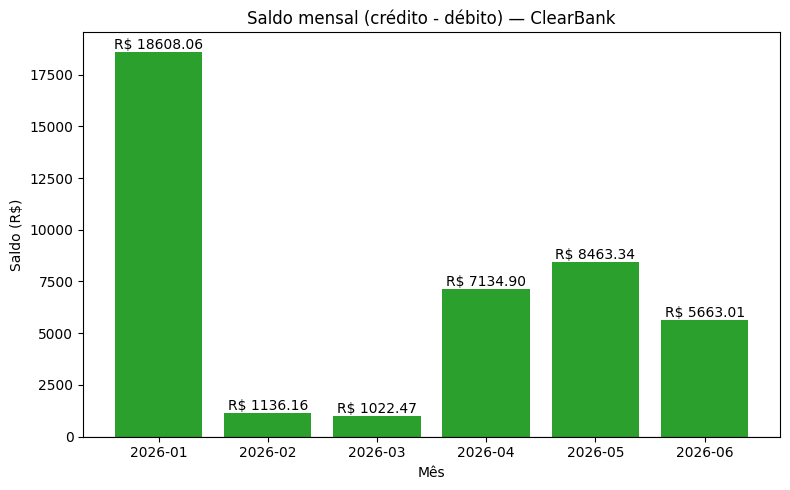

Gráfico salvo em grafico.png


In [136]:
import matplotlib.pyplot as plt

def gerar_grafico(resumo_mensal: dict, caminho: str = "grafico.png") -> None:
    """Gráfico de barras com o saldo mensal (crédito - débito). Salva em grafico.png."""
    meses = list(resumo_mensal.keys())
    saldos = [d["saldo"] for d in resumo_mensal.values()]
    cores = ["tab:green" if s >= 0 else "tab:red" for s in saldos]

    fig, ax = plt.subplots(figsize=(8, 5))
    barras = ax.bar(meses, saldos, color=cores)
    ax.set_title("Saldo mensal (crédito - débito) — ClearBank")
    ax.set_xlabel("Mês")
    ax.set_ylabel("Saldo (R$)")
    ax.axhline(0, color="black", linewidth=0.8)
    ax.bar_label(barras, fmt="R$ %.2f")

    fig.tight_layout()
    fig.savefig(caminho, dpi=150)
    plt.show()

gerar_grafico(resumo_mensal)
print("Gráfico salvo em grafico.png")
